## Part A - Image Feature Extraction and Classification

In [3]:
import cv2  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [4]:
crack_folder = "448/Cracks"
noncrack_folder = "448/NonCracks"

print("Crack images: ", len(os.listdir(crack_folder)))
print("Non-Crack images: ", len(os.listdir(noncrack_folder)))

Crack images:  200
Non-Crack images:  200


### read sample images using OpenCV

In [5]:
crack_file = os.listdir(crack_folder)[0]
noncrack_file = os.listdir(noncrack_folder)[0]

crack_path = os.path.join(crack_folder,crack_file)
noncrack_path = os.path.join(noncrack_folder,noncrack_file)

crack_img = cv2.imread(crack_path)
noncrack_img = cv2.imread(noncrack_path)

print("Crack image shape: ", crack_img.shape)
print("Non-crack image shape: ", noncrack_img.shape)

print("\nCrack image data type: ", crack_img.dtype)
print("Non-crack image data type: ", noncrack_img.dtype)

Crack image shape:  (448, 448, 3)
Non-crack image shape:  (448, 448, 3)

Crack image data type:  uint8
Non-crack image data type:  uint8


### Displaying cracks and non-cracks images

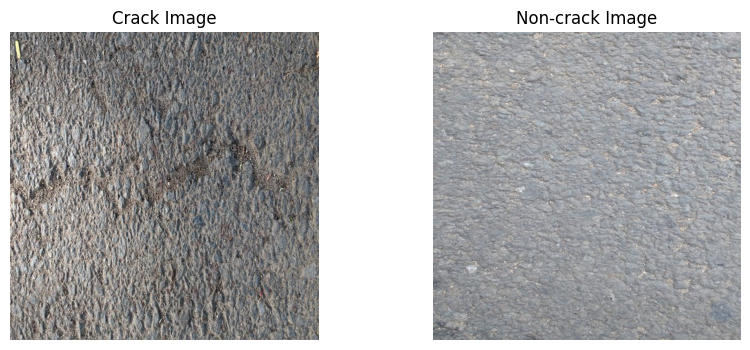

In [6]:
#OpenCV saves image channels in terms of BGR
#Matplotlib saves the same in terms of RGB
#so first we need to convert BGR to RGB

crack_rgb = cv2.cvtColor(crack_img, cv2.COLOR_BGR2RGB)
noncrack_rgb = cv2.cvtColor(noncrack_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
plt.imshow(crack_rgb)
plt.title("Crack Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noncrack_rgb)
plt.title("Non-crack Image")
plt.axis("off")

plt.show()

### Resize and convert to grayscale

In [7]:
IMG_SIZE = (224,224)

crack_resized = cv2.resize(crack_img,IMG_SIZE)
noncrack_resized = cv2.resize(noncrack_img,IMG_SIZE)

crack_gray = cv2.cvtColor(crack_resized, cv2.COLOR_BGR2GRAY)
noncrack_gray = cv2.cvtColor(noncrack_resized, cv2.COLOR_BGR2GRAY)

print("Original Crack Image Shape: ", crack_img.shape)
print("Resized Crack Image Shape: ", crack_resized.shape)
print("Grayscale Crack Image Shape: ", crack_gray.shape)
print("")
print("Original Non-Crack Image Shape: ", noncrack_img.shape)
print("Resized Non-Crack Image Shape: ", noncrack_resized.shape)
print("Grayscale Non-Crack Image Shape: ", noncrack_gray.shape)


Original Crack Image Shape:  (448, 448, 3)
Resized Crack Image Shape:  (224, 224, 3)
Grayscale Crack Image Shape:  (224, 224)

Original Non-Crack Image Shape:  (448, 448, 3)
Resized Non-Crack Image Shape:  (224, 224, 3)
Grayscale Non-Crack Image Shape:  (224, 224)


### Display grascale images

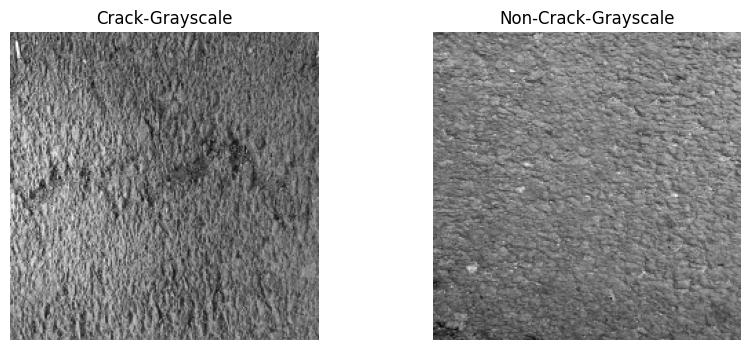

In [8]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(crack_gray, cmap="gray")
plt.title("Crack-Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noncrack_gray, cmap="gray")
plt.title("Non-Crack-Grayscale")
plt.axis("off")

plt.show()

### Extract basic intensity features

In [9]:
mean_brightness = np.mean(crack_gray)
contrast = np.std(crack_gray)
min_intensity = np.min(crack_gray)
max_intensity = np.max(crack_gray)
median_intensity = np.median(crack_gray)

dark_pixel_ratio = np.sum(crack_gray < 50) / crack_gray.size
bright_pixel_ratio = np.sum(crack_gray > 200) / crack_gray.size

print("Mean Brightness: ", mean_brightness)
print("Contrast: ", contrast)
print("Minimum Intensity: ", min_intensity)
print("Maximum Intensity: ", max_intensity)
print("Dark Pixel Ratio: ", dark_pixel_ratio)
print("Bright Pixel Ratio: ", bright_pixel_ratio)


Mean Brightness:  122.224609375
Contrast:  31.51348191896166
Minimum Intensity:  23
Maximum Intensity:  247
Dark Pixel Ratio:  0.0038464604591836736
Bright Pixel Ratio:  0.01092155612244898


### Comparing with non-crack

In [10]:
print("Crack Image")
print("Mean Brightness: ", mean_brightness)
print("Contrast: ", contrast)
print("Dark Pixel ratio: ", dark_pixel_ratio)
print("Bright Pixel Ratio: ", bright_pixel_ratio)

print("\nNon-Crack Image")
print("Mean Brightness: ", np.mean(noncrack_gray))
print("Contrast: ", np.std(noncrack_gray))
print("Dark Pixel Ratio: ", np.sum(noncrack_gray < 50) / noncrack_gray.size)
print("Bright Pixel Ratio: ", np.sum(noncrack_gray > 200) / noncrack_gray.size)

Crack Image
Mean Brightness:  122.224609375
Contrast:  31.51348191896166
Dark Pixel ratio:  0.0038464604591836736
Bright Pixel Ratio:  0.01092155612244898

Non-Crack Image
Mean Brightness:  157.35797991071428
Contrast:  15.472834291792829
Dark Pixel Ratio:  0.0
Bright Pixel Ratio:  0.003946109693877551


### Canny edge detection

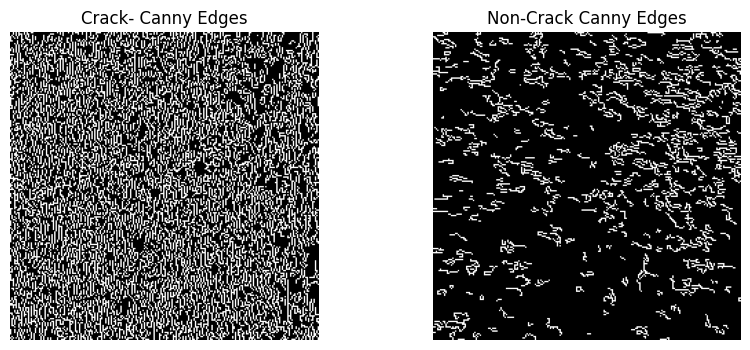

In [11]:
crack_edges = cv2.Canny(crack_gray, 100, 200)
noncrack_edges = cv2.Canny(noncrack_gray, 100, 200)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(crack_edges, cmap="gray")
plt.title("Crack- Canny Edges")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noncrack_edges, cmap="gray")
plt.title("Non-Crack Canny Edges")
plt.axis("off")

plt.show()

### Calculating edge count and edge density

In [12]:
crack_edge_count = np.count_nonzero(crack_edges)
noncrack_edge_count = np.count_nonzero(noncrack_edges)

crack_edge_density = crack_edge_count / crack_edges.size
noncrack_edge_density = noncrack_edge_count / noncrack_edges.size

print("Crack Image: ")
print("Edge Count: ", crack_edge_count)
print("Edge Density: ", crack_edge_density)


print("\nNon-Crack Image: ")
print("Edge Count: ", noncrack_edge_count)
print("Edge Density: ", noncrack_edge_density)

Crack Image: 
Edge Count:  17232
Edge Density:  0.3434311224489796

Non-Crack Image: 
Edge Count:  5621
Edge Density:  0.11202566964285714


### Extraxcting features from all the images

In [13]:
def extract_features(image_path):
    img = cv2.imread(image_path)

    img = cv2.resize(img, (224, 224))

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    mean_brightness = np.mean(gray)
    contrast = np.std(gray)
    min_intensity = np.min(gray)
    max_intensity = np.max(gray)
    median_intensity = np.median(gray)

    dark_pixel_ratio = np.sum(gray < 50) / gray.size
    bright_pixel_ratio = np.sum(gray > 200) / gray.size
    edges = cv2.Canny(gray, 100, 200)

    edge_count = np.count_nonzero(edges)
    edge_density = edge_count / edges.size

    return [
        mean_brightness,
        contrast, 
        min_intensity,
        max_intensity,
        median_intensity,
        dark_pixel_ratio,
        bright_pixel_ratio,
        edge_count,
        edge_density
    ]


In [14]:
data = []

#Process for crack images
for filename in os.listdir(crack_folder):
    image_path = os.path.join(crack_folder, filename)
    features = extract_features(image_path)
    data.append([filename] + features + [1])

#Process for non-crack images
for filename in os.listdir(noncrack_folder):
    image_path = os.path.join(noncrack_folder, filename)
    features = extract_features(image_path)
    data.append([filename] + features + [0])

print("Total Images Processed: ", len(data))

Total Images Processed:  400


In [21]:
coulmns = [
    "filename",
    "mean_brightness",
    "contrast", 
    "min_intensity", 
    "max_intensity", 
    "median_intensity",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_count",
    "edge_density",
    "label"
]

features_df = pd.DataFrame(data, columns=coulmns)
print("Dataset Shape: ", features_df.shape)
features_df.head()


Dataset Shape:  (400, 11)


,filename,mean_brightness,contrast,min_intensity,max_intensity,median_intensity,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density,label
0,IMG_20180513_164959951_HDR resized_448.jpg,122.224609,31.513482,23,247,121.0,0.003846,0.010922,17232,0.343431,1
1,IMG_20180513_165129852_HDR resized_448.jpg,131.948681,24.096114,8,251,133.0,0.002790,0.003787,13394,0.266940,1
2,IMG_20180513_165150613_HDR resized_448.jpg,121.297313,29.884272,2,241,121.0,0.013333,0.008171,13185,0.262775,1
3,IMG_20180513_165345878_HDR resized_448.jpg,130.245596,25.649018,20,253,131.0,0.001893,0.004006,16591,0.330656,1
4,IMG_20180513_165349788_HDR resized_448.jpg,131.208885,26.237598,11,254,132.0,0.002372,0.006258,15886,0.316606,1


In [24]:
print(features_df["label"].value_counts())
features_df.to_csv("image_features.csv", index=False)

label
1    200
0    200
Name: count, dtype: int64


In [25]:
X = features_df.drop(columns=["filename", "label"])
y = features_df["label"]

print("X Shape: ", X.shape)
print("y Shape: ", y.shape)
X.head()

X Shape:  (400, 9)
y Shape:  (400,)


,mean_brightness,contrast,min_intensity,max_intensity,median_intensity,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density
0,122.224609,31.513482,23,247,121.0,0.003846,0.010922,17232,0.343431
1,131.948681,24.096114,8,251,133.0,0.002790,0.003787,13394,0.266940
2,121.297313,29.884272,2,241,121.0,0.013333,0.008171,13185,0.262775
3,130.245596,25.649018,20,253,131.0,0.001893,0.004006,16591,0.330656
4,131.208885,26.237598,11,254,132.0,0.002372,0.006258,15886,0.316606


### Train-test split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples: ", X_train.shape[0])
print("Testing Samples: ", y_train.shape[0])

print("\nTraining Class Distribution: ")
print(y_train.value_counts())

print("\nTesting Class Distribution: ")
print(y_test.value_counts())

Training Samples:  320
Testing Samples:  320

Training Class Distribution: 
label
1    160
0    160
Name: count, dtype: int64

Testing Class Distribution: 
label
0    40
1    40
Name: count, dtype: int64


### Feature scaling and training logistic regression

In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
lr_model = LogisticRegression(max_iter=1000)
start_train = time.time()
lr_model.fit(X_train_scaled, y_train)
end_train = time.time()
lr_training_time = end_train - start_train

#predictions
start_predict = time.time()
lr_prediction = lr_model.predict(X_test_scaled)
end_predict = time.time()
lr_prediction_time = end_predict - start_predict

#confusion matrix
lr_accuracy = accuracy_score(y_test, lr_prediction)
lr_precision = precision_score(y_test, lr_prediction)
lr_recall = recall_score(y_test, lr_prediction)
lr_f1 = f1_score(y_test, lr_prediction)
lr_cm = confusion_matrix(y_test, lr_prediction)

print("Logistic Regression Results: ")
print("\nAccuracy: ", lr_accuracy)
print("Precision: ", lr_precision)
print("Recall: ", lr_recall)
print("F1-Score: ", lr_f1)
print("Training Time: ", lr_training_time, "seconds")
print("Prediction Time: ", lr_prediction_time, "seconds")
print("Confusion matrix: \n", lr_cm)

Logistic Regression Results: 

Accuracy:  0.9375
Precision:  0.926829268292683
Recall:  0.95
F1-Score:  0.9382716049382716
Training Time:  0.008263587951660156 seconds
Prediction Time:  0.00039267539978027344 seconds
Confusion matrix: 
 [[37  3]
 [ 2 38]]


### Training Random Forest

In [33]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
start_train = time.time()
rf_model.fit(X_train, y_train)
end_train = time.time()

rf_training_time = end_train - start_train

#predict
start_predict = time.time()
rf_prediction = rf_model.predict(X_test)
end_predict = time.time()
rf_prediction_time = end_predict - start_predict

#matrix
rf_accuracy = accuracy_score(y_test, rf_prediction)
rf_precision = precision_score(y_test, rf_prediction)
rf_recall = recall_score(y_test, rf_prediction)
rf_f1 = f1_score(y_test, rf_prediction)

print("Random Forest Results: ")
print("Accuracy: ", rf_accuracy)
print("Precision: ", rf_precision)
print("Recall: ", rf_recall)
print("F1-Score: ", rf_f1)
print("Training Time: ", rf_training_time, "seconds")
print("Prediction Time: ", rf_prediction_time, "seconds")
print("Confusion matrix: ")
print(confusion_matrix(y_test,rf_prediction))

Random Forest Results: 
Accuracy:  0.95
Precision:  0.95
Recall:  0.95
F1-Score:  0.95
Training Time:  0.17516279220581055 seconds
Prediction Time:  0.0070953369140625 seconds
Confusion matrix: 
[[38  2]
 [ 2 38]]


### Model comparison table

In [35]:
results_df = pd.DataFrame({
    "Model" : ["Logistic Regression", "Random Forest"],
    "Accuracy" : [lr_accuracy, rf_accuracy],
    "Precision" : [lr_precision, rf_precision],
    "Recall" : [lr_recall, rf_recall],
    "F1-Score" : [lr_f1, rf_f1],
    "Training Time(s)" : [lr_training_time, rf_training_time],
    "Prediction Time(s)" : [lr_prediction_time, rf_prediction_time]
})

results_df
results_df.to_csv("image_model_results.csv", index=False)

## Part B - Text Vectorization and Spam Classification

### Loading and inspecting email dataset

In [38]:
from sklearn.feature_extraction.text import CountVectorizer

emails_df = pd.read_csv("emails.csv")
print("Dataset shape: ", emails_df.shape)

print("\n Column Names: ")
print(emails_df.columns)
print("\nFirst 5 rows:")
emails_df.head()



Dataset shape:  (5172, 3002)

 Column Names: 
Index(['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou',
       ...
       'connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military',
       'allowing', 'ff', 'dry', 'Prediction'],
      dtype='str', length=3002)

First 5 rows:


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [40]:
print(emails_df["Prediction"].value_counts())
print("\nClass Distribution (%): ")
print(
    emails_df["Prediction"]
    .value_counts(normalize=True)
    .mul(100)
)

Prediction
0    3672
1    1500
Name: count, dtype: int64

Class Distribution (%): 
Prediction
0    70.99768
1    29.00232
Name: proportion, dtype: float64


### Visualizing the class distribution 

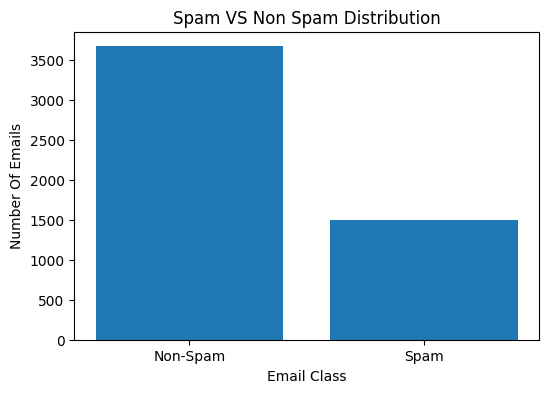

In [39]:
class_counts = emails_df["Prediction"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(
    ["Non-Spam", "Spam"],
    class_counts.values
)
plt.title("Spam VS Non Spam Distribution")
plt.xlabel("Email Class")
plt.ylabel("Number Of Emails")
plt.show()

In [41]:
word_columns = emails_df.columns.drop(["Email No.", "Prediction"])
print("Number of word columns: ", len(word_columns))
print("\nFirst 20 words: ")
print(word_columns[:20].tolist())

Number of word columns:  3000

First 20 words: 
['the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with']


In [43]:
def reconstruct_email(row):
    words = []
    for word in word_columns:
        count = int(row[word])

        if count > 0:
            words.extend([word] * count)
    return " ".join(words)

emails_df["reconstructed_text"] = emails_df.apply(
    reconstruct_email,
    axis=1
)

print(emails_df["reconstructed_text"].iloc[0][:500])

ect a a is i i s s s as re re e e e e t t t t j m m b p c c c r r r r f h u u tu st ic far chris hr rm tr pictures pi ma picture ct ct christmas ur tm


C:\Users\choks\AppData\Local\Temp\ipykernel_25264\1894190511.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  emails_df["reconstructed_text"] = emails_df.apply(


In [46]:
X_text = emails_df["reconstructed_text"]
y_text = emails_df["Prediction"]

print("Number of emails: ", len(X_test))
print("Number of labels: ", len(y_test))

Number of emails:  5172
Number of labels:  5172


In [47]:
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text,
    y_text,
    test_size=0.2,
    random_state=42,
    stratify=y_text

)

print("Training emails: ", len(X_train_text))
print("Testing emails: ", len(X_test_text))

print("\nTraining Distribution: ")
print(y_train_text.value_counts())

print("\nTesting Distribution: ")
print(y_test_text.value_counts())

Training emails:  4137
Testing emails:  1035

Training Distribution: 
Prediction
0    2937
1    1200
Name: count, dtype: int64

Testing Distribution: 
Prediction
0    735
1    300
Name: count, dtype: int64


### Applying CountVectorizer

In [48]:
count_vertorizer = CountVectorizer()

X_train_count = count_vertorizer.fit_transform(X_train_text)
X_test_count = count_vertorizer.transform(X_test_text)

print("Training matrix shape: ", X_train_count.shape)
print("Testing matrix shape: ", X_test_count.shape)

print("Number of features: ", len(count_vertorizer.get_feature_names_out()))

Training matrix shape:  (4137, 2974)
Testing matrix shape:  (1035, 2974)
Number of features:  2974


### Training logistic regression

In [49]:
text_lr_model = LogisticRegression(max_iter=1000)
start_train = time.time()
text_lr_model.fit(X_train_count, y_train_text)
end_train = time.time()
text_lr_training_time = end_train - start_train

#Predict
start_predict = time.time()
text_lr_prediction = text_lr_model.predict(X_test_count)
end_predict = time.time()
text_lr_prediction_time = end_predict - start_predict

text_lr_accuracy = accuracy_score(y_test_text, text_lr_prediction)
text_lr_precision = precision_score(y_test_text, text_lr_prediction)
text_lr_recall = recall_score(y_test_text, text_lr_prediction)
text_lr_f1 = f1_score(y_test_text, text_lr_prediction)

print("Logistic Regression Results: ")
print("Accuracy: ", text_lr_accuracy)
print("Precision: ",text_lr_precision)
print("Recall: ", text_lr_recall)
print("F1-score: ", text_lr_f1)
print("Training time: ", text_lr_training_time, "seconds")
print("Prediction time: ", text_lr_prediction_time, "seconds")

print("\nConfusion Martix: ")
print(confusion_matrix(y_test_text, text_lr_prediction))

Logistic Regression Results: 
Accuracy:  0.9816425120772947
Precision:  0.9546925566343042
Recall:  0.9833333333333333
F1-score:  0.9688013136288999
Training time:  0.6285386085510254 seconds
Prediction time:  0.003955841064453125 seconds

Confusion Martix: 
[[721  14]
 [  5 295]]


### Training multinomial naive bayes


In [50]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
start_train = time.time()
nb_model.fit(X_train_count, y_train_text)
end_train = time.time()
nb_training_time = end_train - start_train

#predict
start_predict = time.time()
nb_prediction = nb_model.predict(X_test_count)
end_predict = time.time()
nb_prediction_time = end_predict - start_predict

nb_accuracy = accuracy_score(y_test_text, nb_prediction)
nb_precision = precision_score(y_test_text, nb_prediction)
nb_recall = recall_score(y_test_text, nb_prediction)
nb_f1 = f1_score(y_test_text, nb_prediction)

print("Multinomial Naive Bayes Results: ")
print("Accuracy: ", nb_accuracy)
print("Precision: ", nb_precision)
print("Recall: ", nb_recall)
print("F1-Score: ", nb_f1)
print("Training time: ", nb_training_time, "secomds")
print("Prediction time: ", nb_prediction_time, "seconds")
print("\nConfusion Martix: ")
print(confusion_matrix(y_test_text,nb_prediction))

Multinomial Naive Bayes Results: 
Accuracy:  0.9420289855072463
Precision:  0.8680981595092024
Recall:  0.9433333333333334
F1-Score:  0.9041533546325878
Training time:  0.053133487701416016 secomds
Prediction time:  0.004881858825683594 seconds

Confusion Martix: 
[[692  43]
 [ 17 283]]


### Comparison table

In [51]:
text_results_df = pd.DataFrame({
    "Model" : [
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],
    "Representation" : [
        "CountVectorizer",
        "CountVectorizer"
    ],
    "Number of Features" : [
        X_train_count.shape[1],
        X_train_count.shape[1]
    ],
    "Accuracy" : [
        text_lr_accuracy,
        nb_accuracy
    ],
    "Precision" : [
        text_lr_precision,
        nb_precision
    ],
    "Recall" : [
        text_lr_recall,
        nb_recall
    ],
    "F1-Score" : [
        text_lr_f1,
        nb_f1
    ],
    "Training time" : [
        text_lr_training_time,
        nb_training_time
    ],
    "Prediction time" : [
        text_lr_prediction_time,
        nb_prediction_time
    ]
})

text_results_df

,Model,Representation,Number of Features,Accuracy,Precision,Recall,F1-Score,Training time,Prediction time
0,Logistic Regression,CountVectorizer,2974,0.981643,0.954693,0.983333,0.968801,0.628539,0.003956
1,Multinomial Naive Bayes,CountVectorizer,2974,0.942029,0.868098,0.943333,0.904153,0.053133,0.004882


In [52]:
text_results_df.to_csv(
    "text_model_results.csv",
    index=False
)

## Part C - Improve the Representation

### Imporving Part-A

In [53]:
def extract_improved_features(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224, 224))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Original Intensity Features
    mean_brightness = np.mean(gray)
    contrast = np.std(gray)
    min_intensity = np.min(gray)
    max_intensity = np.max(gray)
    median_intensity = np.median(gray)
    dark_pixel_ratio = np.sum(gray < 50) / gray.size
    bright_pixel_ratio = np.sum(gray > 200) / gray.size

    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)

    edge_count = np.count_nonzero(edges)
    edge_density = edge_count / edges.size

    return [
        mean_brightness,
        contrast,
        min_intensity,
        max_intensity,
        median_intensity,
        dark_pixel_ratio,
        bright_pixel_ratio,
        edge_count,
        edge_density
    ]

### Visualizing original vs improved canny

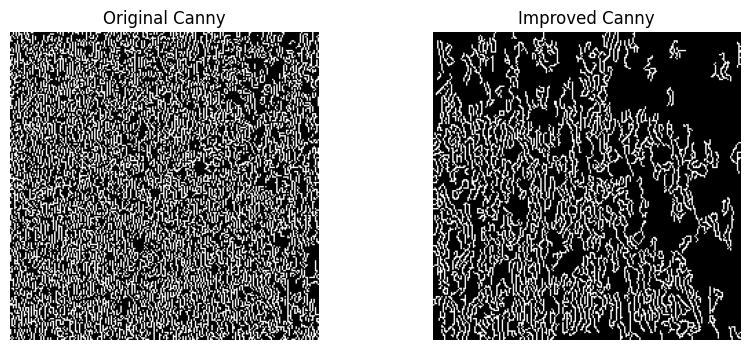

In [55]:
original_edges = cv2.Canny(crack_gray, 100, 200)

blurred_crack = cv2.GaussianBlur(crack_gray, (5, 5), 0)
improved_edges = cv2.Canny(blurred_crack, 50, 150)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_edges, cmap="gray")
plt.title("Original Canny")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(improved_edges, cmap="gray")
plt.title("Improved Canny")
plt.axis("off")

plt.show()

In [56]:
improved_data = []

for filename in os.listdir(crack_folder):
    image_path = os.path.join(crack_folder, filename)
    features = extract_improved_features(image_path)
    improved_data.append([filename] + features + [1])

for filename in os.listdir(noncrack_folder):
    image_path = os.path.join(noncrack_folder, filename)
    features = extract_improved_features(image_path)
    improved_data.append([filename] + features + [0])

improved_features_df = pd.DataFrame(
    improved_data,
    columns=coulmns
)
print("Improved dataset shape: ", improved_features_df.shape)
improved_features_df.head()

Improved dataset shape:  (400, 11)


,filename,mean_brightness,contrast,min_intensity,max_intensity,median_intensity,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density,label
0,IMG_20180513_164959951_HDR resized_448.jpg,122.224609,31.513482,23,247,121.0,0.003846,0.010922,10528,0.209821,1
1,IMG_20180513_165129852_HDR resized_448.jpg,131.948681,24.096114,8,251,133.0,0.002790,0.003787,6178,0.123127,1
2,IMG_20180513_165150613_HDR resized_448.jpg,121.297313,29.884272,2,241,121.0,0.013333,0.008171,7950,0.158442,1
3,IMG_20180513_165345878_HDR resized_448.jpg,130.245596,25.649018,20,253,131.0,0.001893,0.004006,9398,0.187301,1
4,IMG_20180513_165349788_HDR resized_448.jpg,131.208885,26.237598,11,254,132.0,0.002372,0.006258,8411,0.167630,1


In [58]:
X_improved = improved_features_df.drop(
    columns=["filename", "label"]
)

y_umproved = improved_features_df["label"]

#train test split
X_train_improved, X_test_improved, y_train_improved, y_test_improved = train_test_split(
    X_improved,
    y_umproved,
    test_size=0.2,
    random_state=42,
    stratify=y_umproved
)

# training random forest
improved_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
start_train = time.time()
improved_rf_model.fit(
    X_train_improved,
    y_train_improved
)
end_train = time.time()
improved_rf_training_time = end_train - start_train

start_predict = time.time()
improved_rf_predictions = improved_rf_model.predict(
    X_test_improved
)
end_predict = time.time()
improved_rf_prediction_time = end_predict - start_predict

improved_rf_accuracy = accuracy_score(y_test_improved, improved_rf_predictions)
improved_rf_precision = precision_score(y_test_improved, improved_rf_predictions)
improved_rf_recall = recall_score(y_test_improved, improved_rf_predictions)
improved_rf_f1 = f1_score(y_test_improved, improved_rf_predictions)


print("Improved Random Forest Results: ")
print("Accuracy: ", improved_rf_accuracy)
print("Precision: ", improved_rf_precision)
print("Recall: ", improved_rf_recall)
print("F1-Score: ", improved_rf_f1)
print("Training time: ", improved_rf_training_time, "seconds")
print("Prediction time: ", improved_rf_prediction_time, "seconds")
print("\nConfusion Matrix")
print(confusion_matrix(y_test_improved, improved_rf_predictions))

Improved Random Forest Results: 
Accuracy:  0.95
Precision:  0.95
Recall:  0.95
F1-Score:  0.95
Training time:  0.19151616096496582 seconds
Prediction time:  0.012150287628173828 seconds

Confusion Matrix
[[38  2]
 [ 2 38]]


### Improved vs original comparison

In [59]:
part_c_comparison = pd.DataFrame({
    "Approach": [
        "Original Random Forest",
        "Improved Random Forest"
    ],

    "Canny Method": [
        "Gray, thresholds 100-200",
        "Gaussian Blur, thresholds 50-150"
    ],

    "Number of Features": [
        X_train.shape[1],
        X_train_improved.shape[1]
    ],

    "Accuracy": [
        rf_accuracy,
        improved_rf_accuracy
    ],

    "Precision": [
        rf_precision,
        improved_rf_precision
    ],

    "Recall": [
        rf_recall,
        improved_rf_recall
    ],

    "F1-Score": [
        rf_f1,
        improved_rf_f1
    ],

    "Training Time (s)": [
        rf_training_time,
        improved_rf_training_time
    ],

    "Prediction Time (s)": [
        rf_prediction_time,
        improved_rf_prediction_time
    ]
})

part_c_comparison

,Approach,Canny Method,Number of Features,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Original Random Forest,"Gray, thresholds 100-200",9,0.95,0.95,0.95,0.95,0.175163,0.007095
1,Improved Random Forest,"Gaussian Blur, thresholds 50-150",9,0.95,0.95,0.95,0.95,0.191516,0.012150


### Part-C Observation:

##### The original image representation used grayscale images with Canny edge detection thresholds of 100 and 200. To improve the representation, Gaussian Blur was applied before edge detection to reduce small texture-related variations, and the Canny thresholds were changed to 50 and 150. Both approaches generated 9 numerical features per image. The original and modified representations achieved the same accuracy, precision, recall, and F1-score of 95% using Random Forest. Therefore, the modified representation did not improve predictive performance on this train-test split. The measured training and prediction times were also slightly higher for the modified approach, although such small timing differences may vary between runs. This experiment shows that a more complex preprocessing step does not necessarily lead to better classification performance, and the original representation provided the same predictive performance with a simpler preprocessing pipeline. ####